# Rockall Trough glider HYDRO - EOF analysis


<span style="color: red;">**From here not working/still for velocity (cell Seasonal Cycle >31)**</span>

In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append(r'../') # Add this line at the beginner of each notebook to be able to load local functions 
import src.features.RT_functions as rtf
import src.features.RT_data as rtd
import src.features.matfile_functions as matlab_fct
import src.features.RT_transport as rtt
import src.features.RT_EOF_functions as rt_eof
import src.set_paths as sps
import src.RT_parameters as rtp
import src.features.RT_visualise as rtv

C:\Users\sa07kb\Projects\Rockall_Trough_Transports\notebooks\..\src\features\RT_transport.py:9: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [2]:
from matplotlib import pyplot as plt
import dask
import datetime
import gsw
import numpy as np
import pandas as pd
import mat73
import xarray as xr
from pathlib import Path
import xeofs as xe
import warnings
import cmocean as cm
import scipy
warnings.filterwarnings('ignore')
xr.set_options(display_expand_attrs=False)
%matplotlib inline

# Set in- and output path

In [3]:
date_str_start = '2020'
date_str_end = '2025'
fn_version = 'v0'
script_name = f"2.2_Rockall_Trough_glider_EW_EOF_HYDRO_{date_str_start}_{date_str_end}"

# output figures
fig_out_path = (sps.local_fig_dir/f"{script_name}")
Path(fig_out_path).mkdir(parents=True, exist_ok=True)

In [4]:
# mooring intput data
fn_in_version = 'v1'
fn_base_grid = "Rockall_Trough_mooring_gridded_TSUV"
fn_base_stack = "Rockall_Trough_mooring_stacked_TSUV"
date_str_start_moor = '201407'
date_str_end_moor = '202407'

RT_mooring_fn = f"{fn_base_grid}_{date_str_start_moor}_{date_str_end_moor}_{fn_in_version}.nc"
file_name_in_stack = f"{fn_base_stack}_{date_str_start_moor}_{date_str_end_moor}_{fn_in_version}.nc"

# transport input data
fn_in_version = 'v0'
fn_base_grid = "Rockall_Trough_transport_3D_TIME_series"
fn_base_Q_F22= "Rockall_Trough_transport_time_series"
RT_transp_grid_fn = f"{fn_base_grid}_{date_str_start_moor}_{date_str_end_moor}_{fn_in_version}.nc"
RT_transp_Q_F22 = f"{fn_base_Q_F22}_{date_str_start_moor}_{date_str_end_moor}_{fn_in_version}.nc"

prep_RT_mooring_data_path = (sps.local_data_dir/f'0.0_Rockall_Trough_moorings_data_prep_{date_str_start_moor}_{date_str_end_moor}_v0/')
RT_transport_data_path_v0 = (sps.local_data_dir/f'1.0_Rockall_Trough_transports_{date_str_start_moor[:-2]}_{date_str_end_moor[:-2]}_v0/')
RT_transport_data_path_v1 = (sps.local_data_dir/f'3.0_Rockall_Trough_transports_{date_str_start_moor[:-2]}_{date_str_end_moor[:-2]}_v1/')

# Load data

In [5]:
# Rockall Trough mooring location
ds_RT_loc=rtd.load_RT_loc()

# Rockall Trough horizontal grid
RT_hor_grid = rtt.create_horizontal_grid('v1')

# stacked RT mooing data
ds_RT_stacked = rtd.load_RT_moor(file_name_in_stack)

# load gridded Rockall Trough mooring data
ds_RT = rtd.load_RT_moor(RT_mooring_fn)

# Extrapolate top and linearly interpolate over gaps
ds_RT = rtf.prep_mooring_data_for_transport_calc(ds_RT,ds_RT_loc)

# Get dz (top/bottom cells are ~10m thick, cells are ~20m thick elsewhere)
dz = rtt.get_dz(ds_RT.depth)
ds_RT['dz']=xr.DataArray(dz,dims='depth')

# Load  GEBCO bathymetry
ds_GEBCO = xr.open_dataset((sps.GEBCO_data_path/sps.GEBCO_fn))
ds_GEBCO = ds_GEBCO.where(ds_GEBCO.elevation<=0)

# load GLORYS model data
ds_GLORYS = rtd.load_glorys('RTADCP',ds_RT.TIME.min(),ds_RT.TIME.max()).rename({'time':'TIME'})


Load existing data set.
Load existing data set.
Data is in GLORYS reanlysis and interim period


In [6]:
#Reconstructed Rockall Trough transport section
ds_q_RT = xr.open_dataset((RT_transport_data_path_v0/RT_transp_grid_fn))
ds_q_RT_full = ds_q_RT.sel(lon=slice(ds_RT_loc.lon_RTEB.values,None))
ds_q_RT = ds_q_RT_full.sel(depth=slice(None,1000))
dims = ['lon','depth']

# Calc tracer fluxes for upper 1000m
def calc_Q(ds,dims):
    Q = ds.q.sum(dims)/1e6
    Qh = ds.qh.sum(dims)/1e15
    Qf = ds.qf.sum(dims)/1e6
    return xr.merge([Q.rename('Q'),Qh.rename('Qh'),Qf.rename('Qf')],compat='no_conflicts')

ds_Q_F22 = calc_Q(ds_q_RT,dims)

#low pass filter
dt = 0.5 # twice per day, time step of sampling
fs = 1/dt # sample rate (1/day)
lowcut = 1/rtp.filter_length # cut off frequency
ds_Q_F22 = rtf.lp_filt_loop(ds_Q_F22,lowcut,fs,'TIME')

In [7]:
#load glider
ds_glider_mat = matlab_fct.load_glider_mat(sps.glider_data_path,sps.glider_fn)

# # Interpolate glider to EB1 depths
ds_glider_mat['depth']=np.abs(ds_glider_mat.depth)
ds_glider_mat = ds_glider_mat.interp(depth=('depth',ds_RT.depth.data)).rename({'time':'TIME'}).sel(depth=slice(None,1000))
ds_glider_mat_nan = rt_eof.add_nan_glider_sections(ds_glider_mat,dim='TIME')

In [8]:
#load glider nc
ds_glider = rtd.load_glider_nc()

# Interpolate glider to EB1 depths
ds_glider['depth']=np.abs(ds_glider.depth)
ds_glider = ds_glider.interp(depth=('depth',ds_RT.depth.data)).rename({'time':'TIME'}).sel(depth=slice(None,1000))
ds_glider_nan = rt_eof.add_nan_glider_sections(ds_glider,dim='TIME')

## Mean Glider section

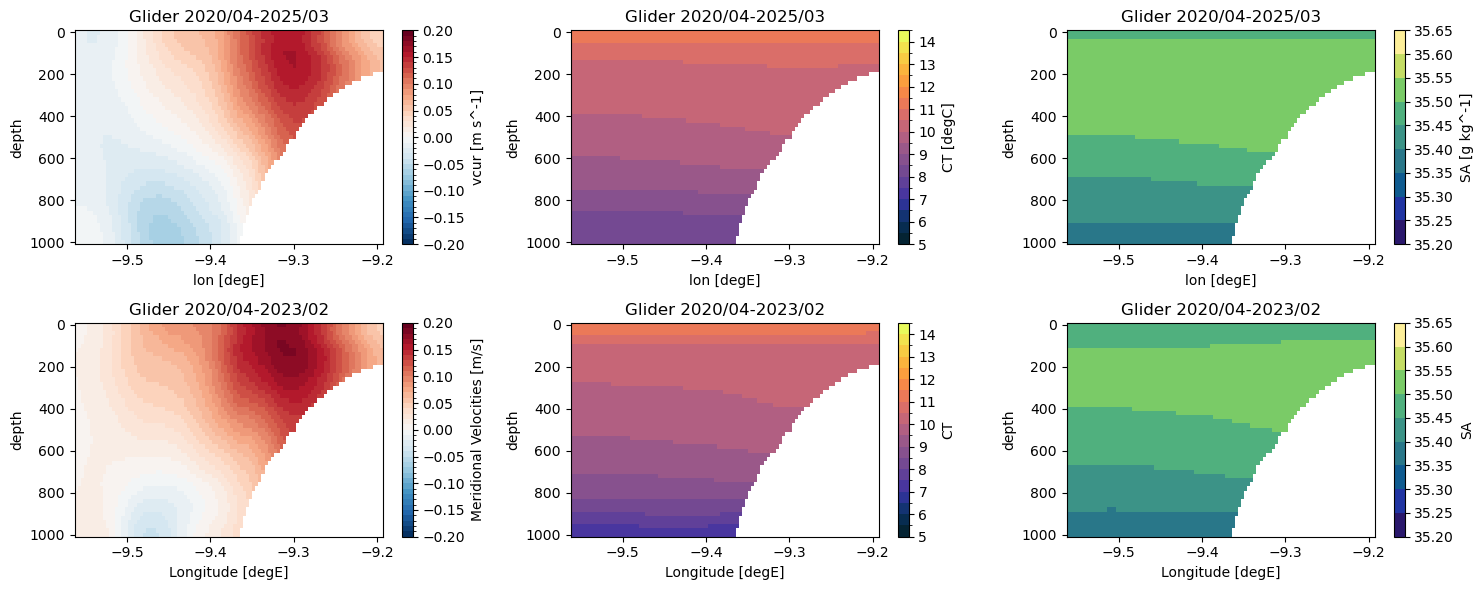

In [9]:
fig,axs = plt.subplots(2,3,figsize=[15,6])
vmin,vmax,levs=-0.2,0.2,41
tem_levs = np.arange(5,15,.5)
sal_levs = np.arange(35.2,35.7,.05)


ax=axs[0,0]
ds_glider.vcur.mean(['TIME']).plot(x='lon',ax=ax,yincrease=False,
                                   vmin=vmin,vmax=vmax,levels=levs,cmap='RdBu_r')
ax.set_title(f'Glider {ds_glider.TIME.min().dt.strftime("%Y/%m").values
            }-{ds_glider.TIME.max().dt.strftime("%Y/%m").values}')

ax=axs[0,1]
ds_glider.CT.mean(['TIME']).plot(x='lon',ax=ax,yincrease=False,
                                   levels=tem_levs,cmap=cm.cm.thermal)
ax.set_title(f'Glider {ds_glider.TIME.min().dt.strftime("%Y/%m").values
            }-{ds_glider.TIME.max().dt.strftime("%Y/%m").values}')

ax=axs[0,2]
ds_glider.SA.mean(['TIME']).plot(x='lon',ax=ax,yincrease=False,
                                   levels=sal_levs,cmap=cm.cm.haline)
ax.set_title(f'Glider {ds_glider.TIME.min().dt.strftime("%Y/%m").values
            }-{ds_glider.TIME.max().dt.strftime("%Y/%m").values}')

ax=axs[1,0]
ds_glider_mat.vcur.mean(['TIME']).plot(x='lon',ax=ax,yincrease=False,
                                   vmin=vmin,vmax=vmax,levels=levs,cmap='RdBu_r')
ax.set_title(f'Glider {ds_glider_mat.TIME.min().dt.strftime("%Y/%m").values
            }-{ds_glider_mat.TIME.max().dt.strftime("%Y/%m").values}')

ax=axs[1,1]
ds_glider_mat.CT.mean(['TIME']).plot(x='lon',ax=ax,yincrease=False,
                                   levels=tem_levs,cmap=cm.cm.thermal)
ax.set_title(f'Glider {ds_glider_mat.TIME.min().dt.strftime("%Y/%m").values
            }-{ds_glider_mat.TIME.max().dt.strftime("%Y/%m").values}')

ax=axs[1,2]
ds_glider_mat.SA.mean(['TIME']).plot(x='lon',ax=ax,yincrease=False,
                                   levels=sal_levs,cmap=cm.cm.haline)
ax.set_title(f'Glider {ds_glider_mat.TIME.min().dt.strftime("%Y/%m").values
            }-{ds_glider_mat.TIME.max().dt.strftime("%Y/%m").values}')

plt.tight_layout()

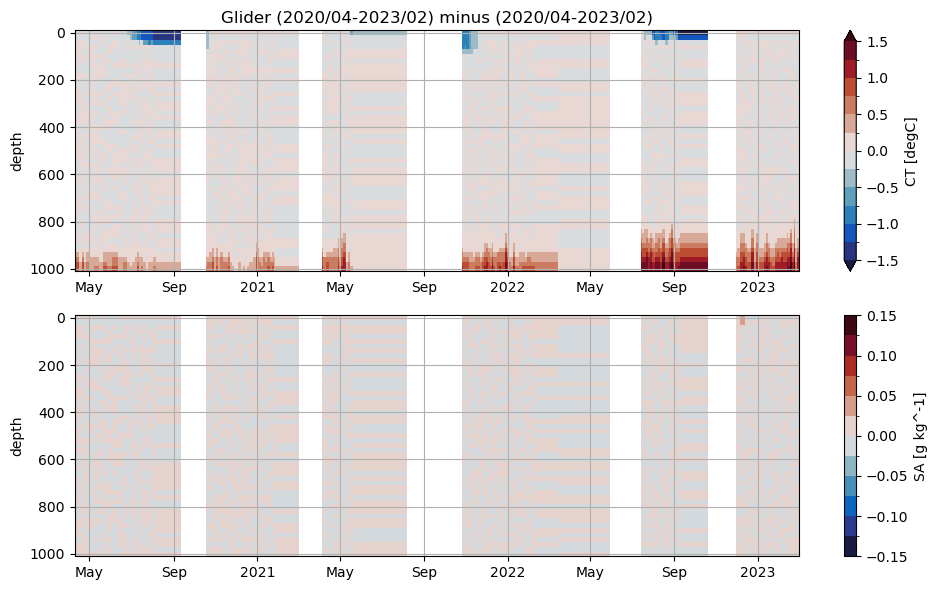

In [10]:
fig,axs = plt.subplots(2,1,figsize=[10,6])

tem_levs = np.arange(-1.5,1.52,.25)
sal_levs = np.arange(-0.15,0.152,0.025)

ax=axs[0]
(ds_glider_nan.CT-ds_glider_mat_nan.CT).mean(['lon']
                        ).plot(ax=ax,x='TIME',yincrease=False,
                       levels=tem_levs,cmap=cm.cm.balance)
                                                    
ax.set_title(f'Glider ({ds_glider_mat.TIME.min().dt.strftime("%Y/%m").values
            }-{ds_glider_mat.TIME.max().dt.strftime("%Y/%m").values
            }) minus ({ds_glider_mat.TIME.min().dt.strftime("%Y/%m").values
            }-{ds_glider_mat.TIME.max().dt.strftime("%Y/%m").values})')

ax=axs[1]
(ds_glider_nan.SA-ds_glider_mat_nan.SA).mean(['lon']
                        ).plot(ax=ax,x='TIME',yincrease=False,
                        levels=sal_levs, cmap=cm.cm.balance)

for ax in axs:
    ax.grid()
    ax.set_xlabel('')

plt.tight_layout()

### Volume, heat and freshwater transports

In [11]:
def calc_transport_VHF(ds,dims,sec_str):
    dx = gsw.distance(ds.vcur.lon[:2],ds.lat[:2])
    dz = rtt.get_dz(ds.vcur.depth)
    q = ds.vcur.rename('q')*dx*dz
    Q = q.sum(dims)*1e-6
    Q.attrs = {'long_name':'Volume Transport','units':'Sv'}

    ds_Q,ds_q = rtt.calc_transports(Q,q,ds.CT,ds.SA,dims,sec_str)
    
    return ds_Q,ds_q

In [12]:
# for now using old data set because of  data issue in updated nc file
ds_glider = ds_glider_mat
ds_glider_nan = ds_glider_mat_nan

## Calculate transports from glider sections
dims = ['lon','depth']

# Calc tracer fluxes for upper 1000m
ds_glider_Q,ds_glider_q = calc_transport_VHF(ds_glider,dims,'glider')
ds_glider_Q = rt_eof.add_nan_glider_sections(ds_glider_Q,dim='TIME')

# Calc tracer fluxes using RT mooring data
ds_glider_moor = ds_q_RT[['CT','SA']].interp_like(ds_glider)
ds_glider_moor ['vcur'] = ds_glider.vcur
ds_gl_moor_Q,ds_gl_moor_q = calc_transport_VHF(ds_glider_moor,dims,'glider')
ds_gl_moor_Q = rt_eof.add_nan_glider_sections(ds_gl_moor_Q,dim='TIME')

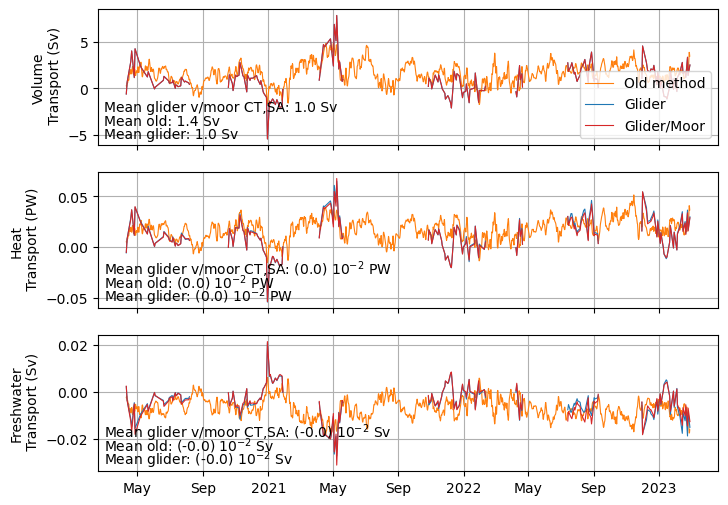

In [13]:
fig,axs = plt.subplots(3,1,sharex=True,figsize=[8,6])

ylabel_name = ['Volume\n Transport (Sv)','Heat\n Transport (PW)','Freshwater\n Transport (Sv)']
# build a rectangle in axes coords
left = .01
bottom = .05

# print(SE.values)
# print(SEh.values)
# print(SEf.values) Q_MB_grid

ax = axs[0]
ds_Q_F22.Q.sel(TIME=slice(ds_glider.TIME.min().values,ds_glider.TIME.max().values)
                         ).plot.line('C1',ax=ax,linewidth=.8,label='Old method')
ds_glider_Q.Q.plot.line('C0',ax=ax,linewidth=.8,label='Glider')
ds_gl_moor_Q.Q.plot.line('C3',ax=ax,linewidth=.8,label='Glider/Moor')

ax.text(left, bottom+0.1, (r'Mean old: %2.1f Sv' %(ds_Q_F22.Q.mean().values)),
        fontsize=10,
        transform=ax.transAxes)
ax.text(left, bottom, (r'Mean glider: %2.1f Sv' %(ds_glider_Q.Q.mean().values)),
        fontsize=10,
        transform=ax.transAxes)
ax.text(left, bottom+0.2, (r'Mean glider v/moor CT,SA: %2.1f Sv' %(ds_gl_moor_Q.Q.mean().values)),
        fontsize=10,
        transform=ax.transAxes)
ax.legend()

ax = axs[1]
ds_Q_F22.Qh.sel(TIME=slice(ds_glider.TIME.min().values,ds_glider.TIME.max().values)
                         ).plot.line('C1',ax=ax,linewidth=.8)
ds_glider_Q.Qh.plot.line('C0',ax=ax,linewidth=.8)
ds_gl_moor_Q.Qh.plot.line('C3',ax=ax,linewidth=.8)

ax.text(left, bottom+0.1, (r'Mean old: (%2.1f) 10$^{-2}$ PW' %(ds_Q_F22.Qh.mean().values)),
        fontsize=10,
        transform=ax.transAxes)
ax.text(left, bottom, (r'Mean glider: (%2.1f) 10$^{-2}$ PW' %(ds_glider_Q.Qh.mean().values)),
        fontsize=10,
        transform=ax.transAxes)
ax.text(left, bottom+0.2, (r'Mean glider v/moor CT,SA: (%2.1f) 10$^{-2}$ PW' %(ds_gl_moor_Q.Qh.mean().values)),
        fontsize=10,
        transform=ax.transAxes)

ax = axs[2]
ds_Q_F22.Qf.sel(TIME=slice(ds_glider.TIME.min().values,ds_glider.TIME.max().values)
                         ).plot.line('C1',ax=ax,linewidth=.8)
ds_glider_Q.Qf.plot.line('C0',ax=ax,linewidth=.8)
ds_gl_moor_Q.Qf.plot.line('C3',ax=ax,linewidth=.8)

ax.text(left, bottom+0.1, (r'Mean old: (%2.1f) 10$^{-2}$ Sv' %(ds_Q_F22.Qf.mean().values)),
        fontsize=10,
        transform=ax.transAxes)
ax.text(left, bottom, (r'Mean glider: (%2.1f) 10$^{-2}$ Sv' %(ds_glider_Q.Qf.mean().values)),
        fontsize=10,
        transform=ax.transAxes)
ax.text(left, bottom+0.2, (r'Mean glider v/moor CT,SA: (%2.1f) 10$^{-2}$ Sv' %(ds_gl_moor_Q.Qf.mean().values)),
        fontsize=10,
        transform=ax.transAxes)

for i,ax in enumerate(axs):
    ax.grid()
    ax.set_title('')
    ax.set_ylabel(ylabel_name[i])
    ax.set_xlabel('')

# fig.savefig(fig_out_path/f'Rockall_Trough_F22u1000m_transports_{date_str_start}_{date_str_end}_{fn_out_version}.png',dpi=300,bbox_inches='tight')

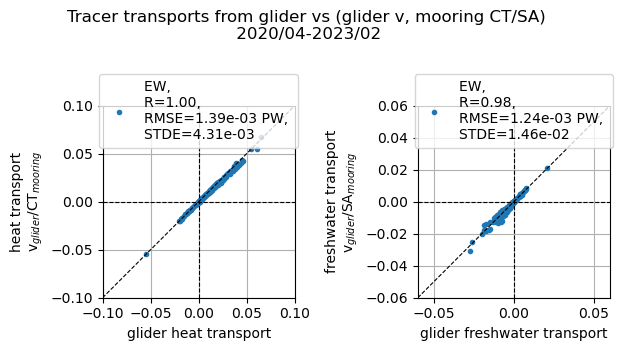

In [14]:
fig,axs = plt.subplots(1,2)
ax = axs[0]
rt_eof.plot_linregress(ds_glider_Q.Qh.dropna('TIME'),
                    ds_gl_moor_Q.Qh.dropna('TIME'),
                    axs=ax,
                    label_str = 'EW',
                    xlabel_str = 'glider heat transport',
                    ylabel_str = f'heat transport\n{r'v$_{glider}$/CT$_{mooring}$'}', 
                    unit_str='PW', ylim=np.array([-10, 10])*1e-2, xlim=np.array([-10,10])*1e-2)
ax = axs[1]
rt_eof.plot_linregress(ds_glider_Q.Qf.dropna('TIME'),
                    ds_gl_moor_Q.Qf.dropna('TIME'),
                    axs=ax,
                    label_str = 'EW',
                    xlabel_str = 'glider freshwater transport',
                    ylabel_str = f"freshwater transport\n{r'v$_{glider}$/SA$_{mooring}$'}", 
                    unit_str='PW', ylim=np.array([-6, 6])*1e-2, xlim=np.array([-6, 6])*1e-2)
fig.suptitle(f'Tracer transports from glider vs (glider v, mooring CT/SA)\n {rtv.date_str_func(ds_glider)}',
             y=0.85)
plt.tight_layout()

# EOF

### Glider data
Resampled to 15 days and mean removed

### Temperature
### HEOF & EOF

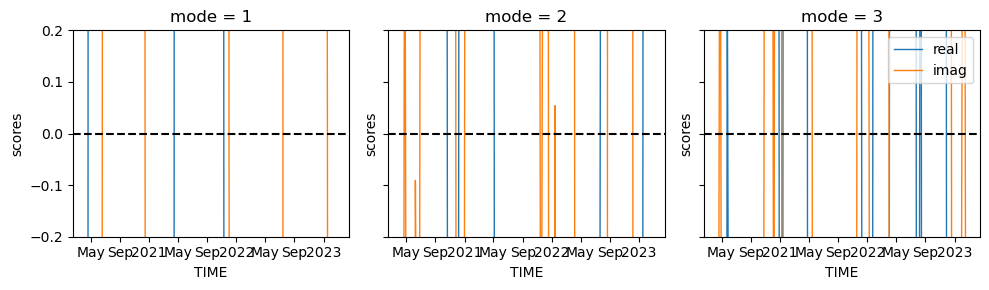

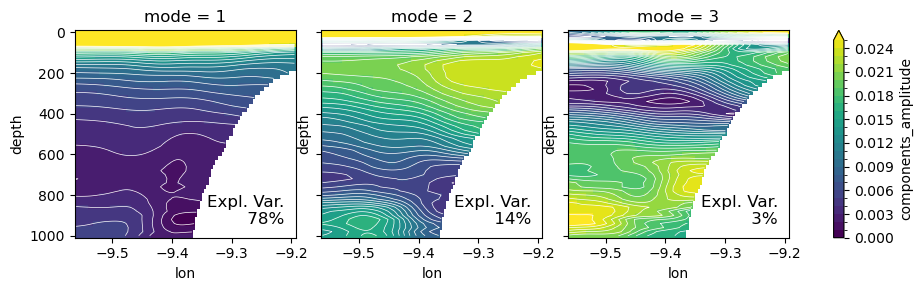

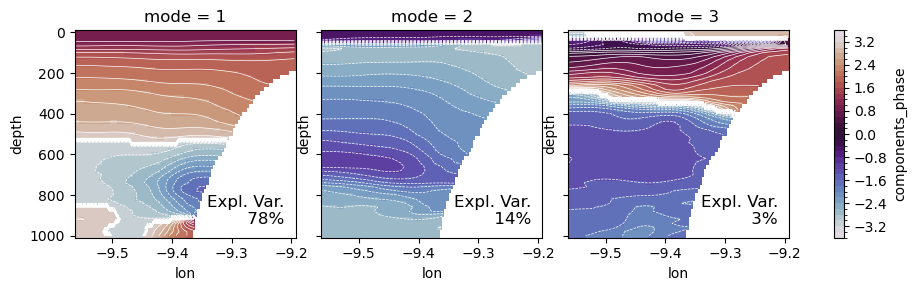

Text(0.5, 0.98, 'EOF')

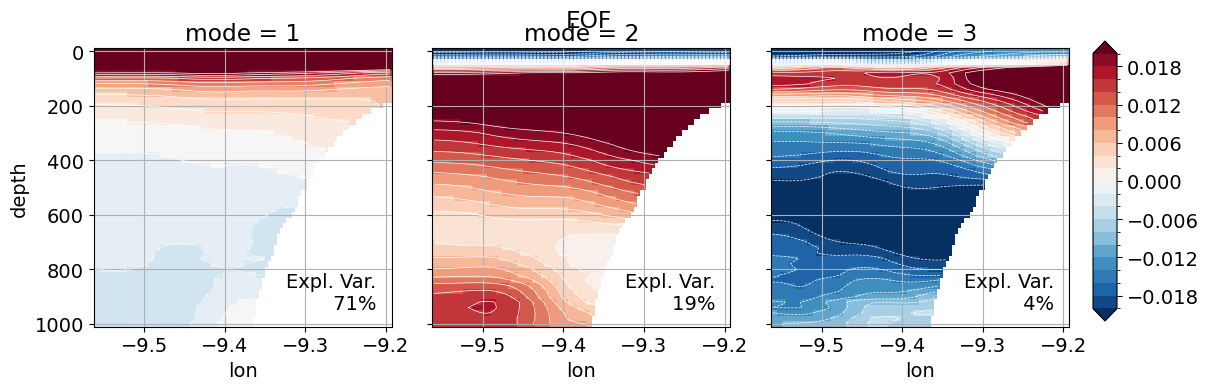

In [15]:
# temperature
da_anomaly = ds_glider.CT.resample(TIME="15D").mean()
da_anomaly = da_anomaly - da_anomaly.mean('TIME',keep_attrs=True)

glider_HEOF = rt_eof.HEOF_func(da_anomaly,n_modes=3,dim='lon')
glider_EOF = rt_eof.EOF_func(da_anomaly,n_modes=3,dim='lon',plot_out=False)
fig = rt_eof.plot_EOF(glider_EOF,dim='lon',EOF=True)
fig.suptitle('EOF')

EOF and HEOF again quite similar... so go with EOF

Similar explained variances as velocity - make sense as it is derived form T and S
First EOF explains 71%, strong signal at surface, weaker and of opposite sign below 400m

### Salinity

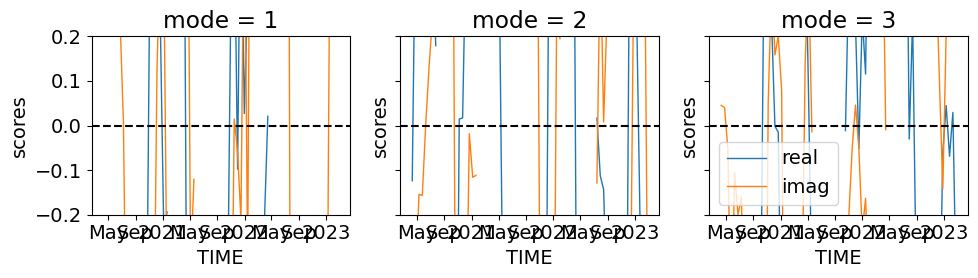

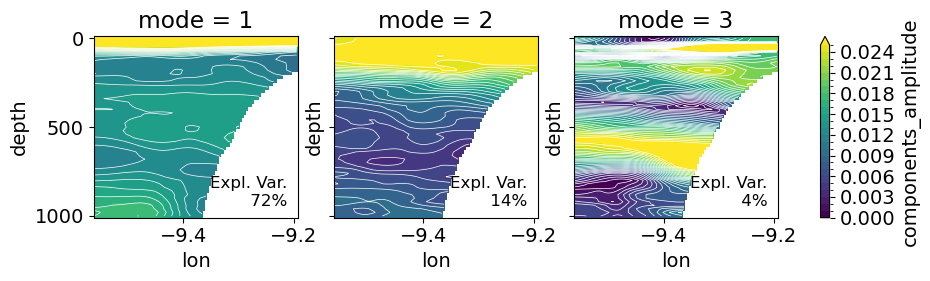

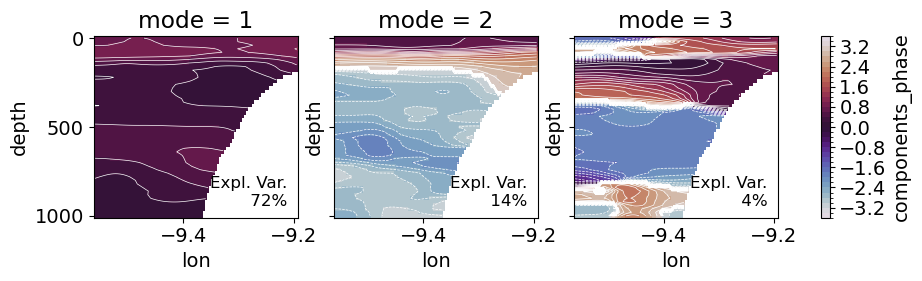

Text(0.5, 0.98, 'EOF')

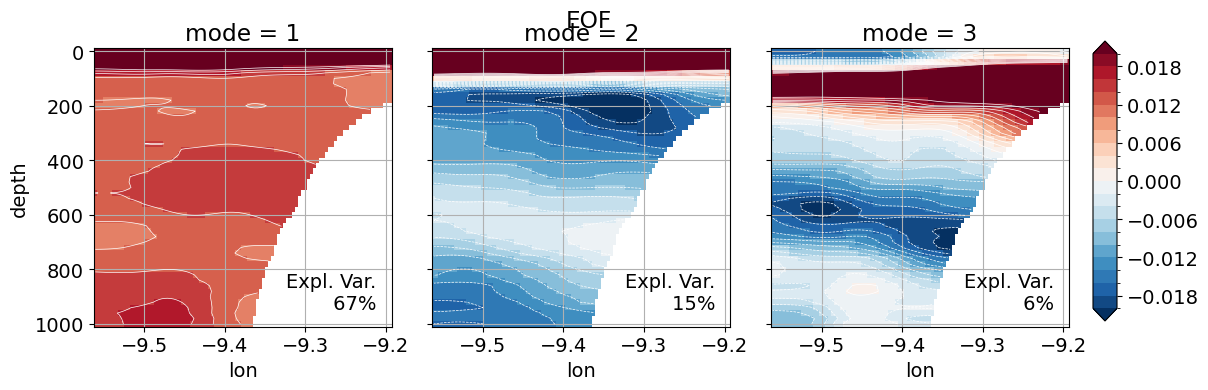

In [16]:
# salinity
da_anomaly = ds_glider.SA.resample(TIME="15D").mean()
da_anomaly = da_anomaly - da_anomaly.mean('TIME',keep_attrs=True)

glider_HEOF = rt_eof.HEOF_func(da_anomaly,n_modes=3,dim='lon')
glider_EOF = rt_eof.EOF_func(da_anomaly,n_modes=3,dim='lon',plot_out=False)
fig = rt_eof.plot_EOF(glider_EOF,dim='lon',EOF=True)
fig.suptitle('EOF')

Again similar HEOF and EOF, so go with EOF
Similar explained variances as T and v.

EOF 1: gerneral strengthening, highest amplitude at surface (miced layer?), higher applitudes betwee 400/600m which might be the transition zone between ESC and under current as well as in undercurrent core below 800m centered around 9.5degW

### Rockall EW reconstruction
#### Full time series (2014-2024) 
original resolution, mean removed


Period 2014/07-2024/07


Text(0.5, 0.98, 'Temperature')

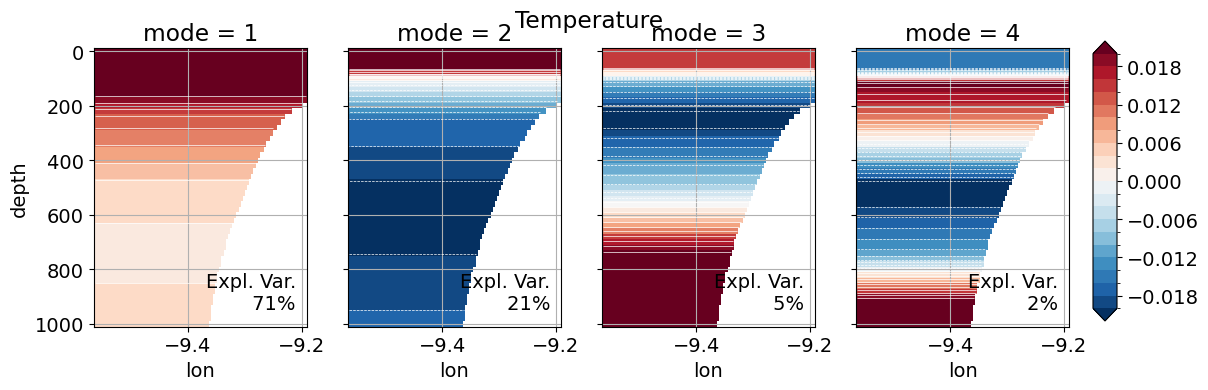

In [17]:
# temperature
da_anomaly = ds_q_RT.CT
print(f'Period {rtv.date_str_func(da_anomaly)}')

# remove mean
da_anomaly = da_anomaly - da_anomaly.mean('TIME',keep_attrs=True)

model = rt_eof.EOF_func(da_anomaly,dim='lon',plot_out=False)
fig = rt_eof.plot_EOF(model,dim='lon',EOF=True)
fig.suptitle('Temperature')

Period 2014/07-2024/07


Text(0.5, 0.98, 'Salinity')

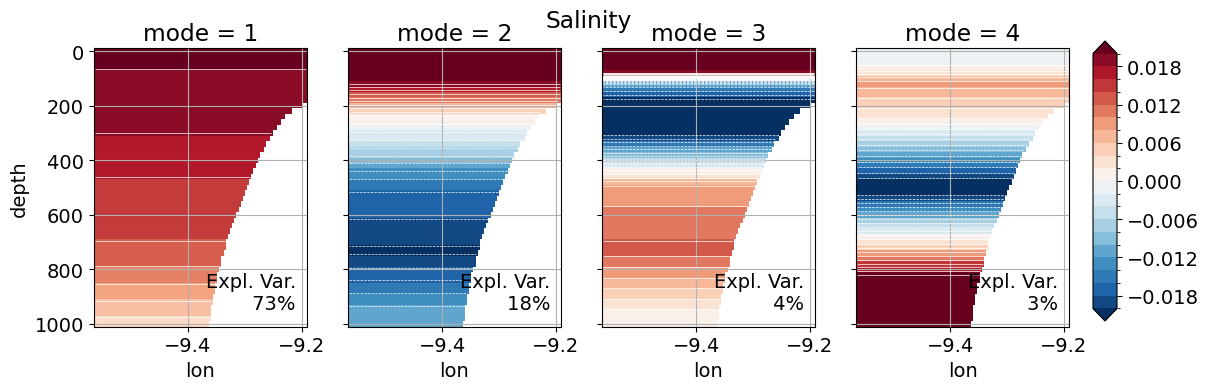

In [18]:
#Salinity
da_anomaly = ds_q_RT.SA

print(f'Period {rtv.date_str_func(da_anomaly)}')

# remove mean
da_anomaly = da_anomaly - da_anomaly.mean('TIME',keep_attrs=True)

model = rt_eof.EOF_func(da_anomaly,dim='lon',plot_out=False)
fig = rt_eof.plot_EOF(model,dim='lon',EOF=True)

fig.suptitle('Salinity')

#### Interp on glider TIME stamps
15D averaged and mean removed

Period 2020/04-2023/02


Text(0.5, 0.98, 'Temperature')

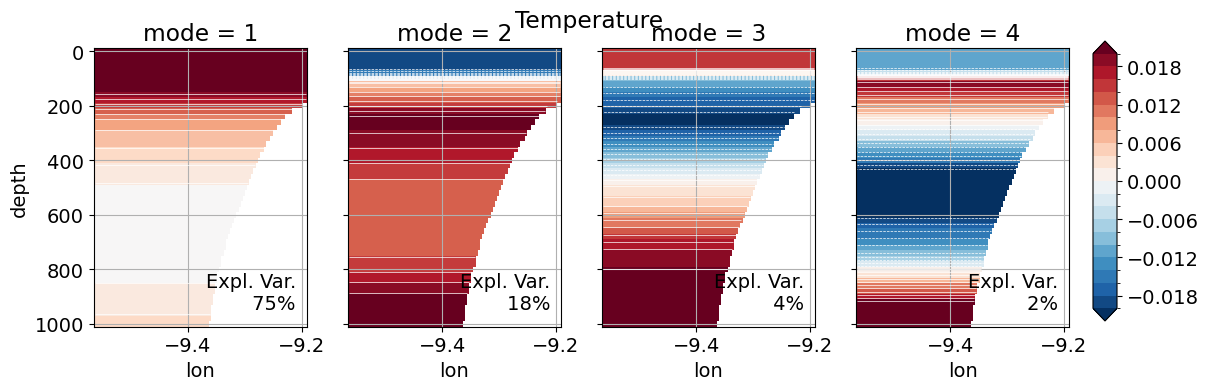

In [19]:
# temperature
da_anomaly = ds_q_RT.CT.interp(TIME=ds_glider.TIME.values)
print(f'Period {rtv.date_str_func(da_anomaly)}')

# remove mean
da_anomaly = da_anomaly.resample(TIME="15D").mean()
da_anomaly = da_anomaly - da_anomaly.mean('TIME',keep_attrs=True)

model = rt_eof.EOF_func(da_anomaly,dim='lon',plot_out=False)
fig = rt_eof.plot_EOF(model,dim='lon',EOF=True)
fig.suptitle('Temperature')

Period 2020/04-2023/02


Text(0.5, 0.98, 'Salinity')

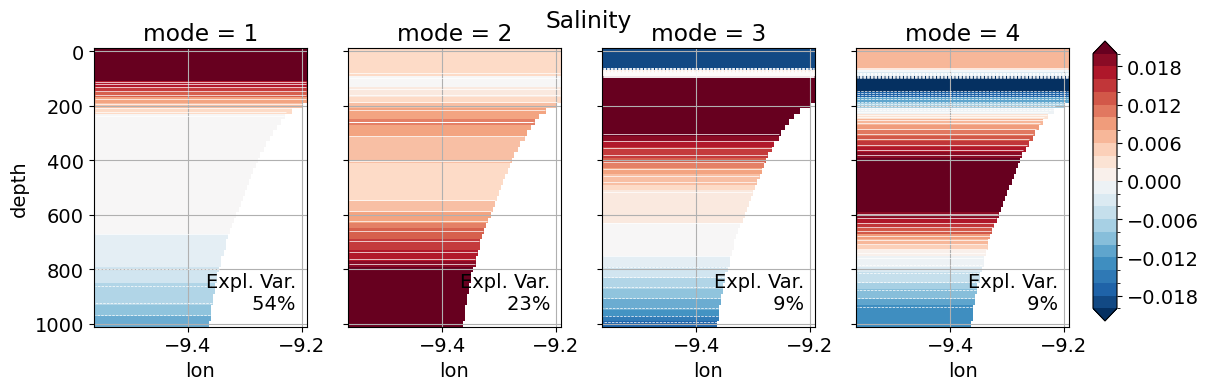

In [20]:
# salinity
da_anomaly = ds_q_RT.SA.interp(TIME=ds_glider.TIME.values)
print(f'Period {rtv.date_str_func(da_anomaly)}')

# remove mean
da_anomaly = da_anomaly.resample(TIME="15D").mean()
da_anomaly = da_anomaly - da_anomaly.mean('TIME',keep_attrs=True)

model = rt_eof.EOF_func(da_anomaly,dim='lon',plot_out=False)
fig = rt_eof.plot_EOF(model,dim='lon',EOF=True)

fig.suptitle('Salinity')

# Reconstruction
Idea: Use the spatial pattern from the EOF ($X$) reproduce velocity section ($y$) for the eastern wedge:
$$
X \alpha = y
$$

Therefore we first need to find alpha. We know y at certain locations: the meridional velocities from RTEB1 and GLORYS2v12-ADCP. We can stack them together to get $y_{loc}$, use the EOF at the mooring positions ($X_{loc}$) and find alpha by solving:

$$
X_{loc}^{T}X_{loc} \alpha = X_{loc}^{T}y_{loc}
$$
$$
\alpha = (X_{loc}^{T}X_{loc})^{-1} X_{loc}^{T}y_{loc}
$$



## Error estimation
## reconstructed mean tracer from EOFs versus mean tracers from  origional glider sections
Recreate glider section using glider obs at point of ERTEB1 for some stats

## Use only EB1 as we do not have sal/temp measurements elsewhere

In [21]:
# Create y from glider data for linear regression (X'X*alpha=X'y)
#get mean glider section at mooring positions
glider_locs = ds_glider.CT.sel(lon=[ds_RT_loc.lon_RTEB],method='nearest')


# Remove glider sections temporal mean from X
ds_y= (glider_locs - glider_locs.mean('TIME')).compute()

# get EOF components at mooring positions as X for linear regression (X'X*alpha=X'y)
# initial X matrix (mode,lon,depth)
ds_X = glider_EOF.components().sel(lon=[ds_RT_loc.lon_RTEB],method='nearest').compute()

# get alpha & reconstruct velocity fields
v_rec_glider_moor_EB1 = rt_eof.rec_v_sec(ds_X,ds_y,glider_EOF,ds_glider.CT)
ds_glider['CT_rec_EB1'] = v_rec_glider_moor_EB1

In [22]:
# Create y from glider data for linear regression (X'X*alpha=X'y)
#get mean glider section at mooring positions
glider_locs = ds_glider.SA.sel(lon=[ds_RT_loc.lon_RTEB],method='nearest')


# Remove glider sections temporal mean from X
ds_y= (glider_locs - glider_locs.mean('TIME')).compute()

# get EOF components at mooring positions as X for linear regression (X'X*alpha=X'y)
# initial X matrix (mode,lon,depth)
ds_X = glider_EOF.components().sel(lon=[ds_RT_loc.lon_RTEB],method='nearest').compute()

# get alpha & reconstruct velocity fields
v_rec_glider_moor_EB1 = rt_eof.rec_v_sec(ds_X,ds_y,glider_EOF,ds_glider.SA)
ds_glider['SA_rec_EB1'] = v_rec_glider_moor_EB1

Text(0.5, 1.0, 'Original vs reconstr. (using only EB1 location) glider sections 2020/04-2023/02')

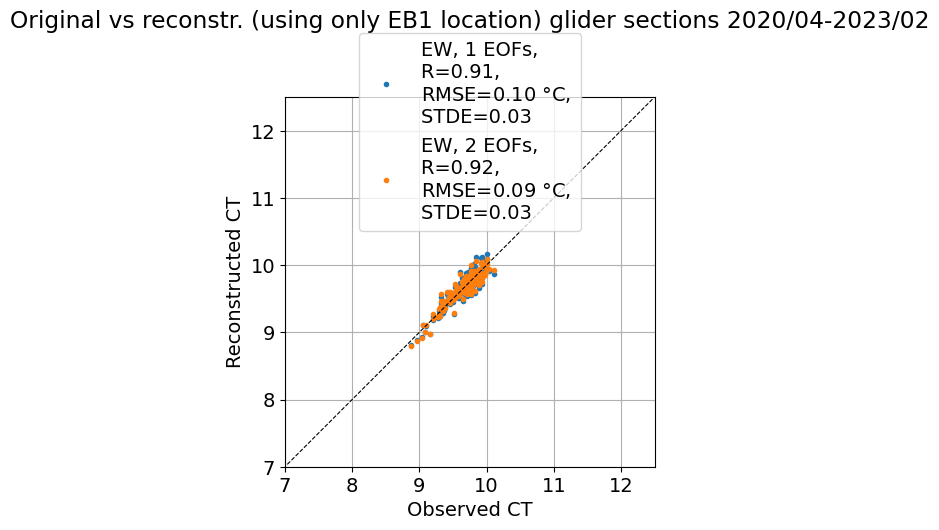

In [23]:
fig,axs = plt.subplots(1,1)
rt_eof.plot_error(ds_glider.CT.mean(['lon','depth']),
                  ds_glider.CT_rec_EB1.mean(['lon','depth']),
                  2,axs,var_str='CT')
plt.title(f'Original vs reconstr. (using only EB1 location) glider sections {rtv.date_str_func(ds_glider)}', pad=50)

Text(0.5, 1.0, 'Original vs reconstr. (using only EB1 location) glider sections 2020/04-2023/02')

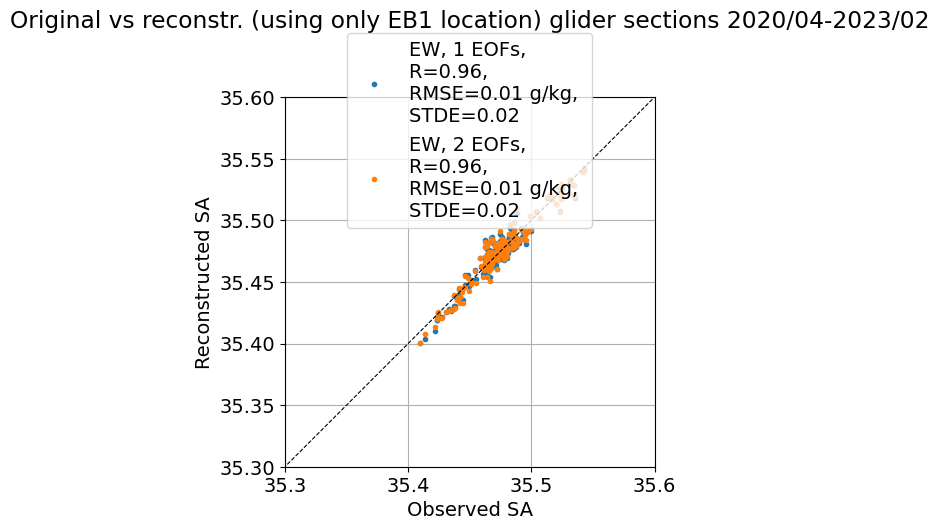

In [24]:
fig,axs = plt.subplots(1,1)
rt_eof.plot_error(ds_glider.SA.mean(['lon','depth']),
                  ds_glider.SA_rec_EB1.mean(['lon','depth']),
                  2,axs,var_str='SA')
plt.title(f'Original vs reconstr. (using only EB1 location) glider sections {rtv.date_str_func(ds_glider)}', pad=50)

## Recreate sections from moorings

## Velocity

In [25]:
# Create y from moored velocity data for linear regression (X'X*alpha=X'y)

# Get RTEB1 meridional velocity
v_RTEB1=(ds_RT.V_EAST/1e2)

#get mean glider section at mooring positions
glider_locs = ds_glider.vcur.sel(lon=[ds_RT_loc.lon_RTEB,ds_RT_loc.lon_RTADCP],method='nearest'
                                ).mean('TIME').compute()

# Get Glorys data at ADCP station and apply corretions
v_GLO_RTADCP = ds_GLORYS.vo.interp(longitude=glider_locs.lon.sel(
                    lon=[ds_RT_loc.lon_RTADCP],method='nearest').data,
                    latitude=ds_RT_loc.lat_RTADCP,
                    TIME=('TIME',v_RTEB1.TIME.data),
                    depth=('depth',glider_locs.depth.data)) + rtp.corr_model

# Duplicate top GLORYS-ADCP values
mask = v_GLO_RTADCP
mask = (mask.notnull()+mask.shift(depth=-1).notnull())
v_GLO_RTADCP = v_GLO_RTADCP.interpolate_na(dim="depth", method="nearest", fill_value="extrapolate")
v_GLO_RTADCP = v_GLO_RTADCP.where(mask).rename({'longitude':'lon'})


# combinde both to one matrix (TIME,depth,lon)
ds_y = xr.concat([v_RTEB1,v_GLO_RTADCP.drop_vars(['latitude','lon'])], dim="lon")
ds_y['lon']=glider_locs.lon.data

# Remove glider sections temporal mean from y
ds_y = (ds_y-glider_locs).compute()

# get EOF components at mooring positions as X for linear regression (X'X*alpha=X'y)
# initial X matrix (mode,lon,depth)
ds_X = glider_EOF.components().sel(lon=[ds_RT_loc.lon_RTEB,ds_RT_loc.lon_RTADCP],method='nearest').compute()

# get alpha & reconstruct velocity fields
v_rec = rt_eof.rec_v_sec(ds_X,ds_y,glider_EOF,ds_glider.vcur)

## Temperature

In [26]:
# Create y from moored velocity data for linear regression (X'X*alpha=X'y)
#get mean glider section at mooring positions
glider_locs = ds_glider.CT.sel(lon=[ds_RT_loc.lon_RTEB],method='nearest').mean('TIME').compute()
glider_locs['depth']=np.abs(glider_locs.depth)

# Get RTEB1 temperature
ds_y=(ds_RT.TG_EAST).interp(depth=('depth',glider_locs.depth.data)).drop('PRES')

# Create one matrix (TIME,depth,lon)
ds_y=ds_y.expand_dims({"lon": glider_locs.lon.data})

# Remove glider sections temporal mean from y
ds_y = (ds_y-glider_locs).compute()

# get EOF components at mooring positions as X for linear regression (X'X*alpha=X'y)
# initial X matrix (mode,lon,depth)
ds_X = glider_EOF.components().sel(lon=[ds_RT_loc.lon_RTEB],method='nearest').compute()

# get alpha & reconstruct velocity fields
CT_rec = rt_eof.rec_v_sec(ds_X,ds_y,glider_EOF,ds_glider.CT)

## Salinity

In [27]:
# Create y from moored velocity data for linear regression (X'X*alpha=X'y)
#get mean glider section at mooring positions
glider_locs = ds_glider.SA.sel(lon=[ds_RT_loc.lon_RTEB],method='nearest').mean('TIME').compute()
glider_locs['depth']=np.abs(glider_locs.depth)

# Get RTEB1 salinity
ds_y = (ds_RT.SG_EAST).interp(depth=('depth',glider_locs.depth.data)).drop('PRES')

# Create one matrix (TIME,depth,lon)
ds_y=ds_y.expand_dims(dim={"lon": glider_locs.lon.data})

# Remove glider sections temporal mean from y
ds_y = (ds_y-glider_locs).compute()

# get EOF components at mooring positions as X for linear regression (X'X*alpha=X'y)
# initial X matrix (mode,lon,depth)
ds_X = glider_EOF.components().sel(lon=[ds_RT_loc.lon_RTEB],method='nearest').compute()

# get alpha & reconstruct velocity fields
SA_rec = rt_eof.rec_v_sec(ds_X,ds_y,glider_EOF,ds_glider.SA)

## Mean section of glider, RT EW full and EOF-reconstructions
- Glider - velocity from glider sections May 2020- Feb 2023
- RT EW full - full data set (Jul 2014- Jul 2024) - velocity section from eastern wedge transport reconstruction (Fraser et al., 2024)  
- EOF [X] full - EOF reconstruction averaging over [X] modes for the full mooring TIME period (Jul 2014- Jul 2024)
- EOF [X] resampled - data interpolated on Glider TIME stamp (May 20-Jul 23) using EOF reconstruction averaged over [X] modes 
    !NOTE: mooring TIME series ends in July 2024 and does not cover full glider TIMEseries!

In [28]:
# create a reconstructed dataset
ds_rec= xr.merge([v_rec.rename('vcur'),
                  CT_rec.rename('CT'),
                  SA_rec.rename('SA')],compat="no_conflicts")

## Calculate transports from reconstructed sections
dims = ['lon','depth']

# Calc tracer fluxes for upper 1000m
ds_rec_Q,ds_rec_q = calc_transport_VHF(ds_rec,dims,'EOF reconstruction')

Mean EW section from glider, RTEW from Fraser et. al (2022), EW new (using EB1 & for v only GLORYS with bias correction)


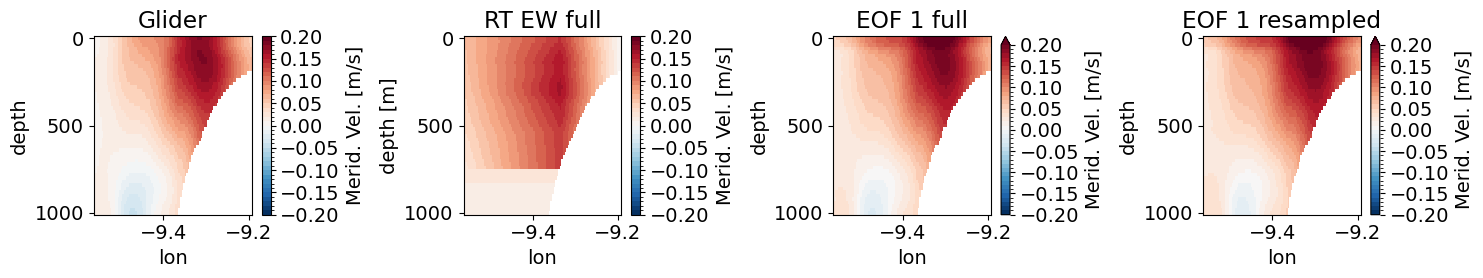

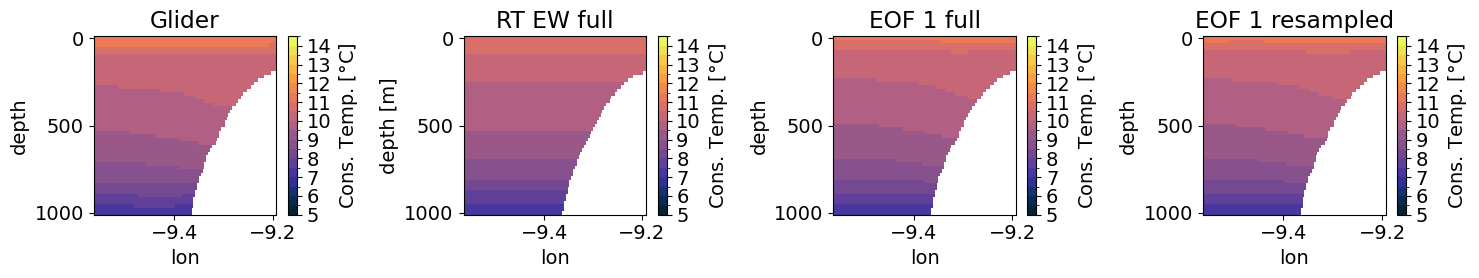

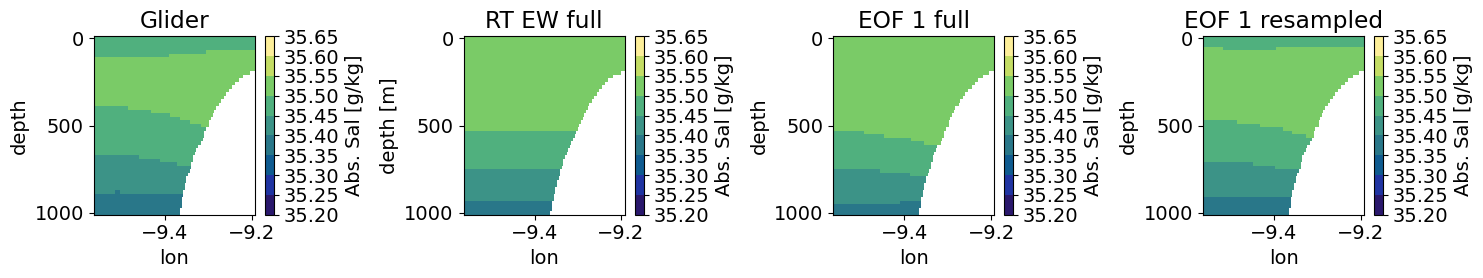

In [29]:
print('Mean EW section from glider, RTEW from Fraser et. al (2022), EW new (using EB1 & for v only GLORYS with bias correction)')
rt_eof.plot_mean_section(ds_glider,ds_q_RT,v_rec)
rt_eof.plot_mean_section(ds_glider,ds_q_RT,CT_rec,var_str='CT')
rt_eof.plot_mean_section(ds_glider,ds_q_RT,SA_rec,var_str='SA')

## Transport time series comparison during glider period

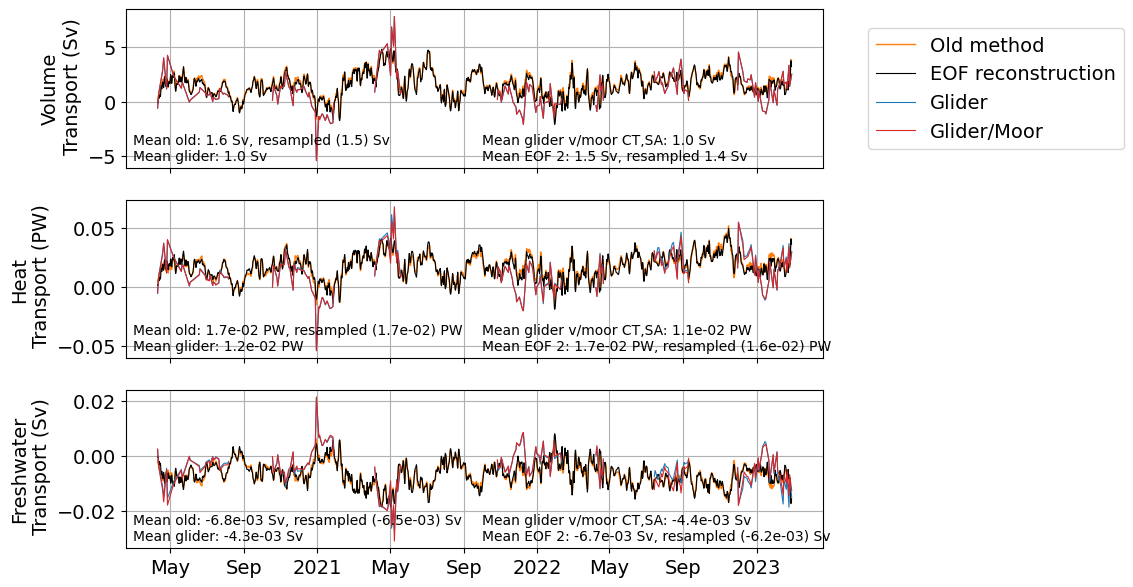

In [30]:
fig,axs = plt.subplots(3,1,sharex=True,figsize=[9,7])

ylabel_name = ['Volume\n Transport (Sv)','Heat\n Transport (PW)','Freshwater\n Transport (Sv)']
# build a rectangle in axes coords
left = .01
bottom = .05

mode_no = 2
ds_rec_Q_dummy = ds_rec_Q.sel(mode=mode_no).sel(
    TIME=slice(ds_glider.TIME.min().values,ds_glider.TIME.max().values))
if 'mode' in ds_rec_Q_dummy.dims:
    ds_rec_Q_dummy = ds_rec_Q_dummy.mean('mode')

ds_Q_F22_dummy = ds_Q_F22.sel(TIME=slice(ds_glider.TIME.min().values,ds_glider.TIME.max().values))

# print(SE.values)
# print(SEh.values)
# print(SEf.values) Q_MB_grid

ax = axs[0]
ds_Q_F22_dummy.Q.sel(TIME=slice(ds_glider.TIME.min().values,ds_glider.TIME.max().values)
                         ).plot.line('C1',ax=ax,linewidth=1,label='Old method')
ds_rec_Q_dummy.Q.plot.line('k',ax=ax,linewidth=.8,label='EOF reconstruction')
ds_glider_Q.Q.plot.line('C0',ax=ax,linewidth=.8,label='Glider')
ds_gl_moor_Q.Q.plot.line('C3',ax=ax,linewidth=.8,label='Glider/Moor')

ax.text(left, bottom+0.1, (r'Mean old: %2.1f Sv, resampled (%2.1f) Sv' %(
                            ds_Q_F22_dummy.Q.mean().values,
                            ds_Q_F22_dummy.Q.interp_like(ds_glider).mean().values)),
                            fontsize=10,
                            transform=ax.transAxes)
ax.text(left, bottom, (r'Mean glider: %2.1f Sv' %(ds_glider_Q.Q.mean().values)),
        fontsize=10,
        transform=ax.transAxes)
ax.text(left+.5, bottom+0.1, (r'Mean glider v/moor CT,SA: %2.1f Sv' %(ds_gl_moor_Q.Q.mean().values)),
        fontsize=10,
        transform=ax.transAxes)
ax.text(left+.5, bottom,(fr'Mean EOF {mode_no}: %2.1f Sv, resampled %2.1f Sv' %((
                                ds_rec_Q_dummy.Q.mean().values,
                                ds_rec_Q_dummy.Q.interp_like(ds_glider).mean().values))),
                                fontsize=10,
                                transform=ax.transAxes)
ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))

ax = axs[1]
ds_Q_F22_dummy.Qh.sel(TIME=slice(ds_glider.TIME.min().values,ds_glider.TIME.max().values)
                         ).plot.line('C1',ax=ax,linewidth=1)
ds_rec_Q_dummy.Qh.plot.line('k',ax=ax,linewidth=.8,label='EOF {mode_no}')
ds_glider_Q.Qh.plot.line('C0',ax=ax,linewidth=.8)
ds_gl_moor_Q.Qh.plot.line('C3',ax=ax,linewidth=.8)

ax.text(left, bottom+0.1, (r'Mean old: %2.1e PW, resampled (%2.1e) PW' %(
                            ds_Q_F22_dummy.Qh.mean().values,
                            ds_Q_F22_dummy.Qh.interp_like(ds_glider).mean().values)),
                            fontsize=10,
                            transform=ax.transAxes)
ax.text(left, bottom, (r'Mean glider: %2.1e PW' %(ds_glider_Q.Qh.mean().values)),
        fontsize=10,
        transform=ax.transAxes)
ax.text(left+.5, bottom+0.1, (r'Mean glider v/moor CT,SA: %2.1e PW' %(ds_gl_moor_Q.Qh.mean().values)),
        fontsize=10,
        transform=ax.transAxes)
ax.text(left+.5, bottom, (fr'Mean EOF {mode_no}: %2.1e PW, resampled (%2.1e) PW' %(
                                ds_rec_Q_dummy.Qh.mean().values,
                                ds_rec_Q_dummy.Qh.interp_like(ds_glider).mean().values)),
                                fontsize=10,
                                transform=ax.transAxes)

ax = axs[2]
ds_Q_F22_dummy.Qf.sel(TIME=slice(ds_glider.TIME.min().values,ds_glider.TIME.max().values)
                         ).plot.line('C1',ax=ax,linewidth=1)
ds_rec_Q_dummy.Qf.plot.line('k',ax=ax,linewidth=.8,label='EOF reconstruction')
ds_glider_Q.Qf.plot.line('C0',ax=ax,linewidth=.8)
ds_gl_moor_Q.Qf.plot.line('C3',ax=ax,linewidth=.8)

ax.text(left, bottom+0.1, (r'Mean old: %2.1e Sv, resampled (%2.1e) Sv' %(
                            ds_Q_F22_dummy.Qf.mean().values,
                            ds_Q_F22_dummy.Qf.interp_like(ds_glider).mean().values)),
                            fontsize=10,
                            transform=ax.transAxes)
ax.text(left, bottom, (r'Mean glider: %2.1e Sv' %(ds_glider_Q.Qf.mean().values)),
        fontsize=10,
        transform=ax.transAxes)
ax.text(left+.5, bottom+0.1, (r'Mean glider v/moor CT,SA: %2.1e Sv' %(ds_gl_moor_Q.Qf.mean().values)),
        fontsize=10,
        transform=ax.transAxes)
ax.text(left+0.5, bottom, (fr'Mean EOF {mode_no}: %2.1e Sv, resampled (%2.1e) Sv' %(
                                ds_rec_Q_dummy.Qf.mean().values,
                                ds_rec_Q_dummy.Qf.interp_like(ds_glider).mean().values)),
                                fontsize=10,
                                transform=ax.transAxes)

for i,ax in enumerate(axs):
    ax.grid()
    ax.set_title('')
    ax.set_ylabel(ylabel_name[i])
    ax.set_xlabel('')


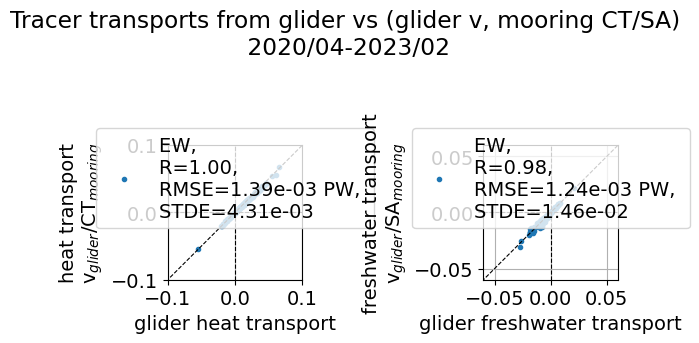

In [31]:
fig,axs = plt.subplots(1,2)
ax = axs[0]
rt_eof.plot_linregress(ds_glider_Q.Qh.dropna('TIME'),
                    ds_gl_moor_Q.Qh.dropna('TIME'),
                    axs=ax,
                    label_str = 'EW',
                    xlabel_str = 'glider heat transport',
                    ylabel_str = f'heat transport\n{r'v$_{glider}$/CT$_{mooring}$'}', 
                    unit_str='PW', ylim=np.array([-10, 10])*1e-2, xlim=np.array([-10,10])*1e-2)
ax = axs[1]
rt_eof.plot_linregress(ds_glider_Q.Qf.dropna('TIME'),
                    ds_gl_moor_Q.Qf.dropna('TIME'),
                    axs=ax,
                    label_str = 'EW',
                    xlabel_str = 'glider freshwater transport',
                    ylabel_str = f"freshwater transport\n{r'v$_{glider}$/SA$_{mooring}$'}", 
                    unit_str='PW', ylim=np.array([-6, 6])*1e-2, xlim=np.array([-6, 6])*1e-2)
fig.suptitle(f'Tracer transports from glider vs (glider v, mooring CT/SA)\n {rtv.date_str_func(ds_glider)}',
             y=0.85)
plt.tight_layout()

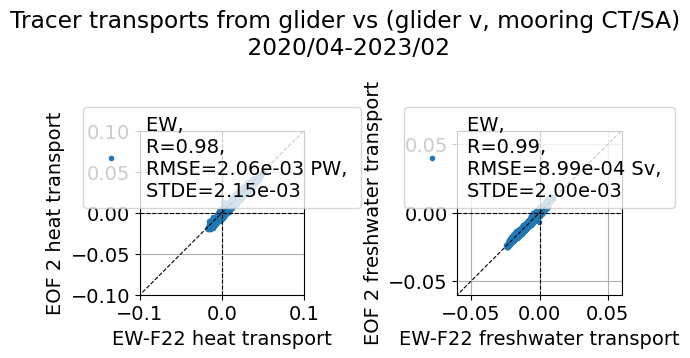

In [32]:
mode_no = 2
ds_rec_Q_dummy = ds_rec_Q.sel(mode=mode_no
                        )#.sel(TIME=slice(ds_glider.TIME.min().values,ds_glider.TIME.max().values))
if 'mode' in ds_rec_Q_dummy.dims:
    ds_rec_Q_dummy = ds_rec_Q_dummy.mean('mode')

ds_Q_F22_dummy = ds_Q_F22#.sel(TIME=slice(ds_glider.TIME.min().values,ds_glider.TIME.max().values))

fig,axs = plt.subplots(1,2)
ax = axs[0]
rt_eof.plot_linregress(ds_Q_F22_dummy.Qh.dropna('TIME'),
                    ds_rec_Q_dummy.Qh.dropna('TIME'),
                    axs=ax,
                    label_str = 'EW',
                    xlabel_str = 'EW-F22 heat transport',
                    ylabel_str = f"EOF {mode_no} heat transport", 
                    unit_str='PW', ylim=np.array([-10, 10])*1e-2, xlim=np.array([-10,10])*1e-2)
ax = axs[1]
rt_eof.plot_linregress(ds_Q_F22_dummy.Qf.dropna('TIME'),
                    ds_rec_Q_dummy.Qf.dropna('TIME'),
                    axs=ax,
                    label_str = 'EW',
                    xlabel_str = f'EW-F22 freshwater transport',
                    ylabel_str = f"EOF {mode_no} freshwater transport", 
                    unit_str='Sv', ylim=np.array([-6, 6])*1e-2, xlim=np.array([-6, 6])*1e-2)
fig.suptitle(f'Tracer transports from glider vs (glider v, mooring CT/SA)\n {rtv.date_str_func(ds_glider)}',
             y=0.85)
plt.tight_layout()

## Seasonal Cycle

<span style="color: red;">**From here not working/still for velocity (cell Seasonal Cycle >31)**</span>

Text(0.5, 1, 'EW new using only EB1')

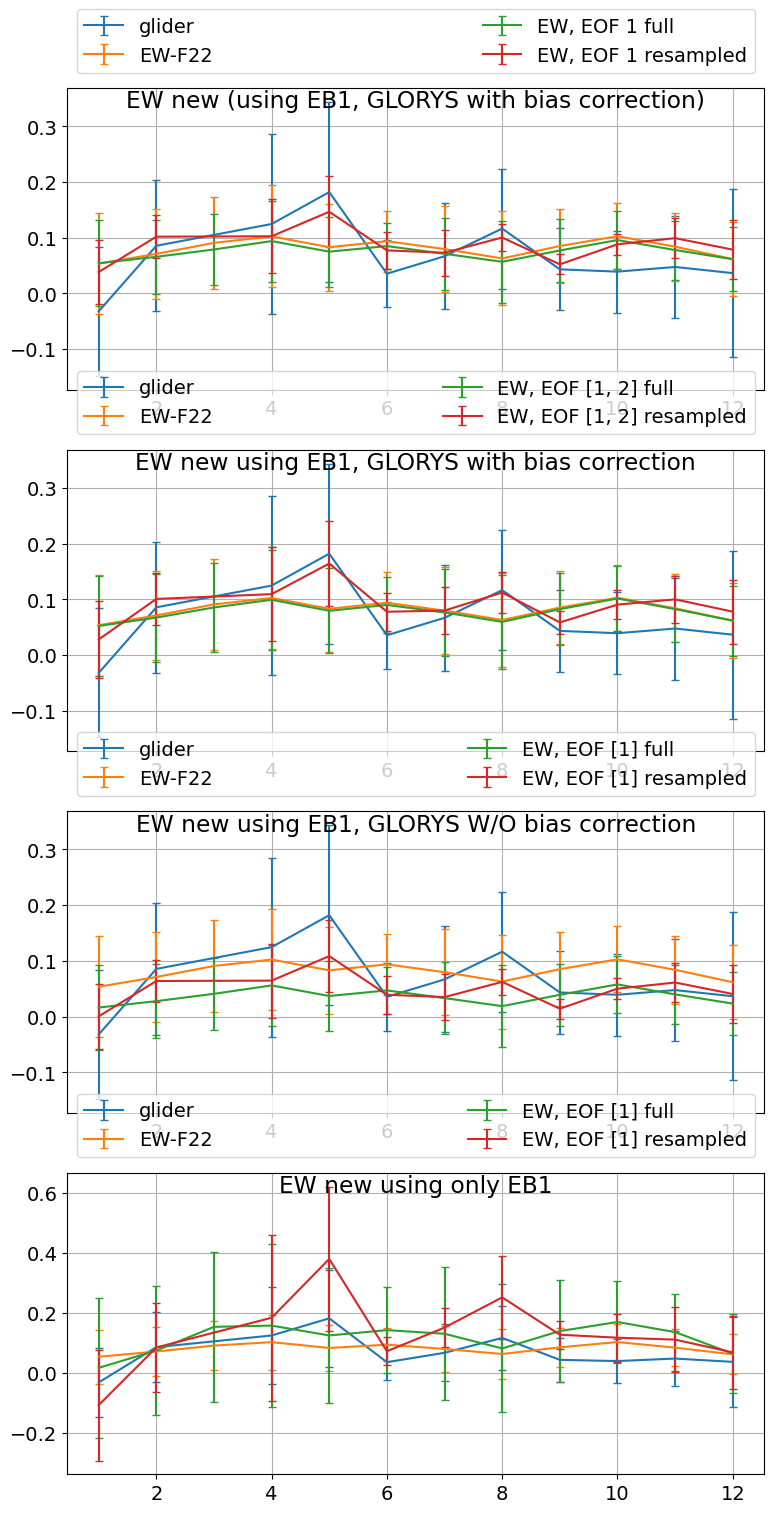

In [31]:
fig,axs = plt.subplots(4,1,figsize=[9,18])
ax=axs[0]
rt_eof.plot_seasonal_cycle(ds_glider_nan,ds_q_RT,v_rec,ax=ax,mode_no=1,mean=False)
ax.set_title('EW new (using EB1, GLORYS with bias correction)',y=1,pad=-14)
ax=axs[1]
rt_eof.plot_seasonal_cycle(ds_glider_nan,ds_q_RT,v_rec,ax=ax,mode_no=[1,2],mean=True)
ax.set_title('EW new using EB1, GLORYS with bias correction',y=1,pad=-14)
ax=axs[2]
rt_eof.plot_seasonal_cycle(ds_glider_nan,ds_q_RT,v_rec_bias,ax=ax,mode_no=[1],mean=True)
ax.set_title('EW new using EB1, GLORYS W/O bias correction',y=1,pad=-14)
ax=axs[3]
rt_eof.plot_seasonal_cycle(ds_glider_nan,ds_q_RT,v_rec_EB1,ax=ax,mode_no=[1],mean=True)
ax.set_title('EW new using only EB1',y=1,pad=-14)

## TIME series in original resolution 2020-2024 - spatially averaged velocity

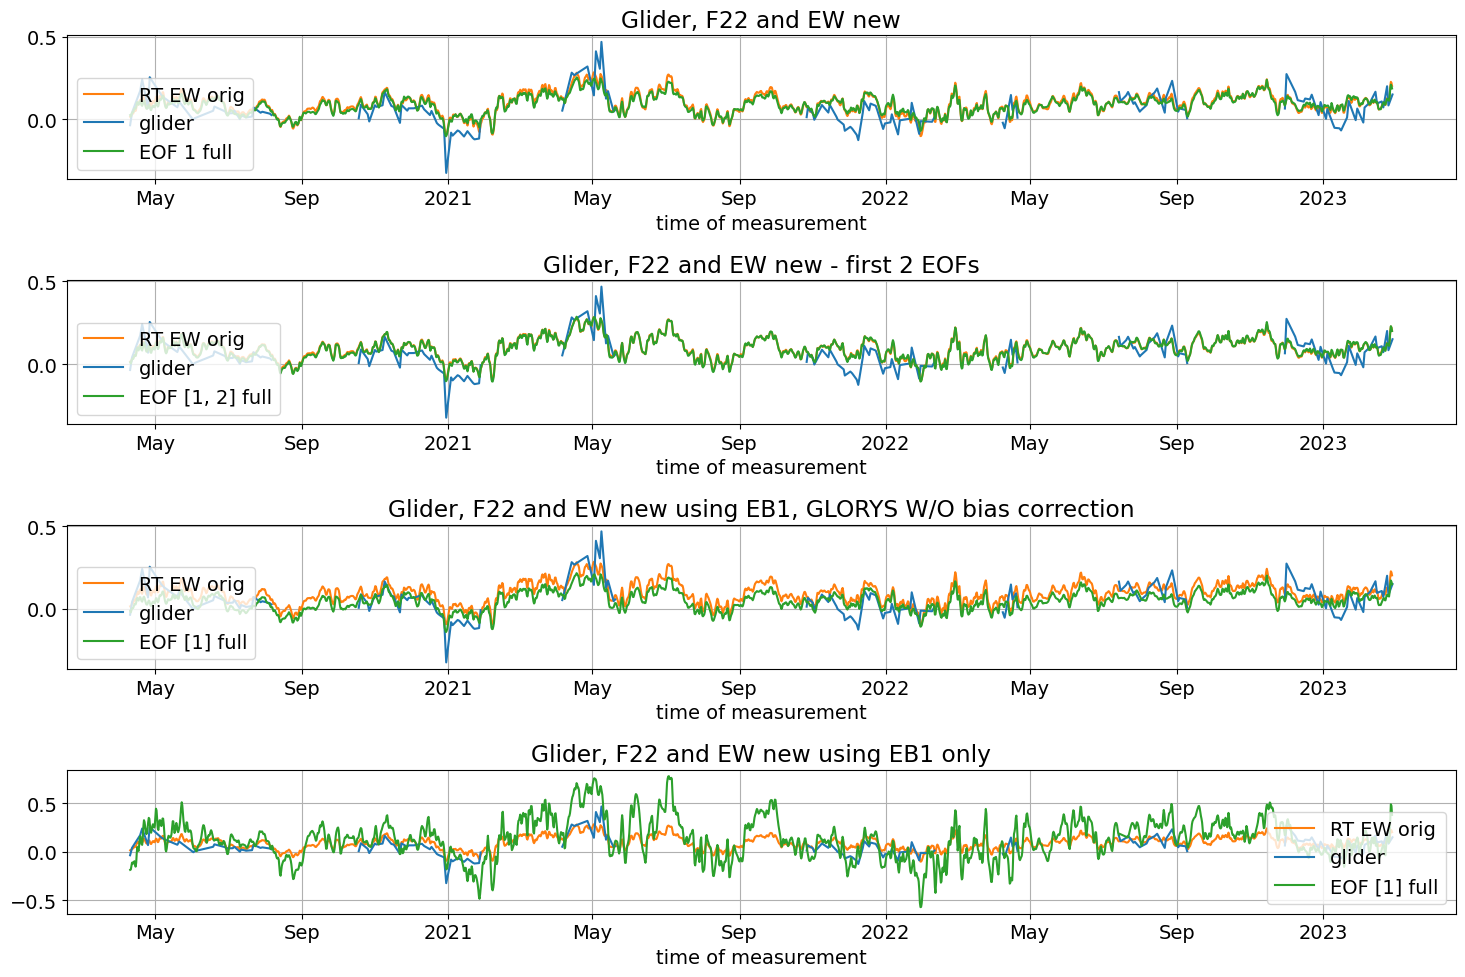

In [32]:
fig,axs = plt.subplots(4,1,figsize=[15,10])
ax=axs[0]
rt_eof.plot_longterm(ds_glider_nan,ds_q_RT,v_rec,ax=ax,mode_no=1,mean=False)
ax.set_title('Glider, F22 and EW new')
ax=axs[1]
rt_eof.plot_longterm(ds_glider_nan,ds_q_RT,v_rec,ax=ax,mode_no=[1,2],mean=True)
ax.set_title('Glider, F22 and EW new - first 2 EOFs')
ax=axs[2]
rt_eof.plot_longterm(ds_glider_nan,ds_q_RT,v_rec_bias,ax=ax,mode_no=[1],mean=True)
ax.set_title('Glider, F22 and EW new using EB1, GLORYS W/O bias correction')
ax=axs[3]
rt_eof.plot_longterm(ds_glider_nan,ds_q_RT,v_rec_EB1,ax=ax,mode_no=[1],mean=True)
ax.set_title('Glider, F22 and EW new using EB1 only')
plt.tight_layout()

EOF mode 1 seems to best to recontruct velocity fields. No additional values gained for variability. Only better representation of slope current structure.

## Reconstructed transport

In [33]:
Q_rec = rt_eof.calc_transport(v_rec)
Q_rec_bias = rt_eof.calc_transport(v_rec_bias)
Q_rec_EB1 = rt_eof.calc_transport(v_rec_EB1)
Q_moor = (ds_q_RT.q.sum(['lon','depth'])*1e-6)
Q_glider_nan = rt_eof.calc_transport(ds_glider_nan.vcur)
Q_glider_nan = Q_glider_nan.where(ds_glider_nan.vcur.isel(depth=0,lon=0).notnull())

Text(0.5, 1.0, 'Glider vs EW new 2020/04-2023/02')

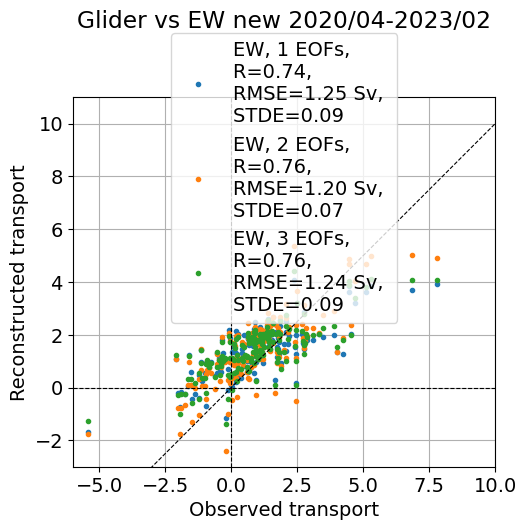

In [34]:
fig,axs = plt.subplots(1,1)
Q_EW_resampled=Q_rec.interp_like(ds_glider.TIME)
Q_EW_resampled=Q_EW_resampled.where(Q_EW_resampled.notnull(),drop=True)
Q_obs = ds_glider.Q.where(Q_EW_resampled.isel(mode=0).notnull(),drop=True)
rt_eof.plot_error(Q_obs,Q_EW_resampled,3,axs)

plt.title(f'Glider vs EW new {rtv.date_str_func(Q_EW_resampled)}', pad=50)

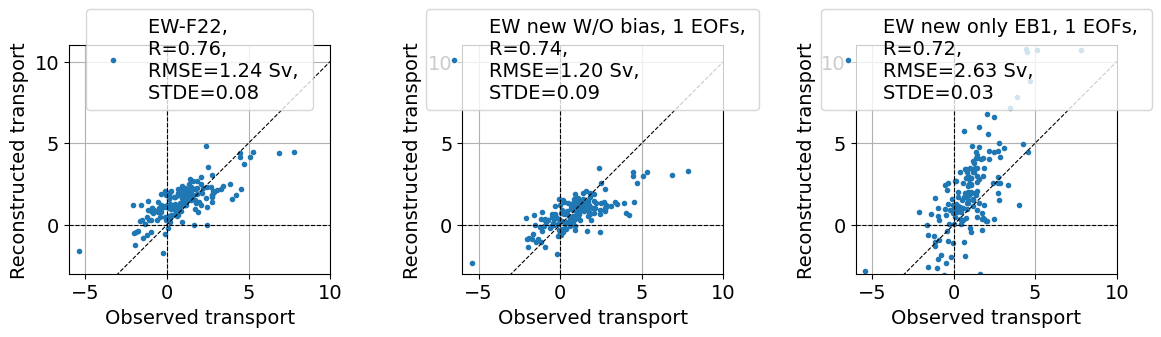

In [35]:
fig,axs = plt.subplots(1,3,figsize=[12,4])
ax = axs[0]
Q_moor_resampled=Q_moor.interp_like(ds_glider.TIME)
Q_moor_resampled=Q_moor_resampled.where(Q_moor_resampled.notnull(),drop=True)
Q_obs = ds_glider.Q.where(Q_moor_resampled.notnull(),drop=True)
rt_eof.plot_error(Q_obs,Q_moor_resampled,0,ax,title_str='EW new')

ax = axs[1]
Q_EW_resampled_bias=Q_rec_bias.interp_like(ds_glider.TIME)
Q_EW_resampled_bias=Q_EW_resampled_bias.where(Q_EW_resampled_bias.notnull(),drop=True)
Q_obs = ds_glider.Q.where(Q_EW_resampled_bias.isel(mode=0).notnull(),drop=True)
rt_eof.plot_error(Q_obs,Q_EW_resampled_bias,1,ax,title_str='EW new W/O bias')

ax = axs[2]
Q_EW_resampled_EB1=Q_rec_EB1.interp_like(ds_glider.TIME)
Q_EW_resampled_EB1=Q_EW_resampled_EB1.where(Q_EW_resampled_EB1.notnull(),drop=True)
Q_obs = ds_glider.Q.where(Q_EW_resampled_EB1.isel(mode=0).notnull(),drop=True)
rt_eof.plot_error(Q_obs,Q_EW_resampled_EB1,1,ax,title_str='EW new only EB1')
plt.tight_layout()

In [36]:
TIME='TIME'

print(f'{pd.to_datetime(Q_glider_nan[TIME].min().values):%b %Y}'+
       f' to {pd.to_datetime(Q_glider_nan[TIME].max().values):%b %Y}'+
       f' glider std error - upper 1000m')
print(f'glider  {Q_glider_nan.mean(TIME).values:2.1f}$\pm$'+
    f'{(rtf.std_error(Q_glider_nan,dim=TIME)).values:2.1f}$\,$Sv'+
       f', STD {Q_glider_nan.std(TIME).values:2.1f}$\,$Sv')

TIME='time'
print(f'{pd.to_datetime(Q_moor.TIME.min().values):%b %Y}'+
       f' to {pd.to_datetime(Q_moor.TIME.max().values):%b %Y}'+
       f' moor std error - upper 1000m')

TIME='TIME'
print(f'EW      {Q_moor.mean(TIME).values:2.1f}$\pm$'+
    f'{(rtf.std_error(Q_moor,dim=TIME)).values:2.1f}$\,$Sv'+
       f', STD {Q_moor.std(TIME).values:2.1f}$\,$Sv')
TIME='TIME'
print(f'EW w/o bias correction {Q_rec_bias.sel(mode=1).mean(TIME).values:2.1f}$\pm$'+
      f'{(rtf.std_error(Q_rec_bias.sel(mode=1),dim=TIME)).values:2.1f}$\,$Sv'+
       f', STD {Q_rec_bias.sel(mode=1).std(TIME).values:2.1f}$\,$Sv')
print(f'EW EB1 only {Q_rec_EB1.sel(mode=1).mean(TIME).values:2.1f}$\pm$'+
    f'{(rtf.std_error(Q_rec_EB1.sel(mode=1),dim=TIME)).values:2.1f}$\,$Sv'+
       f', STD {Q_rec_EB1.sel(mode=1).std(TIME).values:2.1f}$\,$Sv')

Apr 2020 to Feb 2023 glider std error - upper 1000m
glider  1.0$\pm$0.3$\,$Sv, STD 1.7$\,$Sv
Jul 2014 to Jul 2024 moor std error - upper 1000m
EW      1.4$\pm$0.2$\,$Sv, STD 1.2$\,$Sv
EW w/o bias correction 0.6$\pm$0.2$\,$Sv, STD 1.1$\,$Sv
EW EB1 only 1.9$\pm$0.3$\,$Sv, STD 3.4$\,$Sv


In [37]:
print(f'{pd.to_datetime(Q_obs.TIME.min().values):%b %Y}'+
       f' to {pd.to_datetime(Q_obs.TIME.max().values):%b %Y}'+
       f' glider/moor std error - upper 1000m')
print(f'glider  {Q_obs.mean(TIME).values:2.1f}$\pm$'+
    f'{(rtf.std_error(Q_obs,dim=TIME)).values:2.1f}$\,$Sv'+
       f', STD {Q_obs.std(TIME).values:2.1f}$\,$Sv')
print(f'EW      {Q_moor_resampled.mean(TIME).values:2.1f}$\pm$'+
    f'{(rtf.std_error(Q_moor_resampled,dim=TIME)).values:2.1f}$\,$Sv'+
       f', STD {Q_moor_resampled.std(TIME).values:2.1f}$\,$Sv')
print(f'EW w/o bias correction {Q_EW_resampled_bias.sel(mode=1).mean(TIME).values:2.1f}$\pm$'+
      f'{(rtf.std_error(Q_EW_resampled_bias.sel(mode=1),dim=TIME)).values:2.1f}$\,$Sv'+
       f', STD {Q_EW_resampled_bias.sel(mode=1).std(TIME).values:2.1f}$\,$Sv')
print(f'EW EB1 only {Q_EW_resampled_EB1.sel(mode=1).mean(TIME).values:2.1f}$\pm$'+
    f'{(rtf.std_error(Q_EW_resampled_EB1.sel(mode=1),dim=TIME)).values:2.1f}$\,$Sv'+
       f', STD {Q_EW_resampled_EB1.sel(mode=1).std(TIME).values:2.1f}$\,$Sv')

Apr 2020 to Feb 2023 glider/moor std error - upper 1000m
glider  1.0$\pm$0.3$\,$Sv, STD 1.7$\,$Sv
EW      1.5$\pm$0.2$\,$Sv, STD 1.1$\,$Sv
EW w/o bias correction 0.8$\pm$0.2$\,$Sv, STD 0.9$\,$Sv
EW EB1 only 1.7$\pm$0.7$\,$Sv, STD 3.5$\,$Sv


Text(0.5, 1.0, 'EW:= EW new using EB1, GLORYS with bias correction')

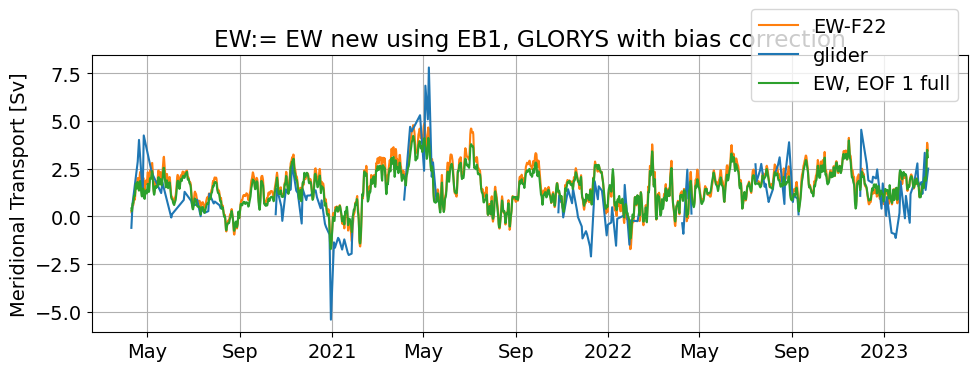

In [38]:
fig,axs = plt.subplots(1,1,figsize=[10,4])
ax=axs
rt_eof.plot_transport(Q_glider_nan,Q_rec,Q_moor,ax=ax,mode_no=1,mean=False)
ax.legend(loc='upper right', bbox_to_anchor=(1.0, 1.2))
ax.set_xlabel('');
plt.tight_layout()
plt.title('EW:= EW new using EB1, GLORYS with bias correction')
# fig.savefig('Glider_eof.png',bbox_inches='tight',dpi=300)

Text(0.5, 1.0, 'EW:= EW new using EB1, GLORYS W/O bias correction')

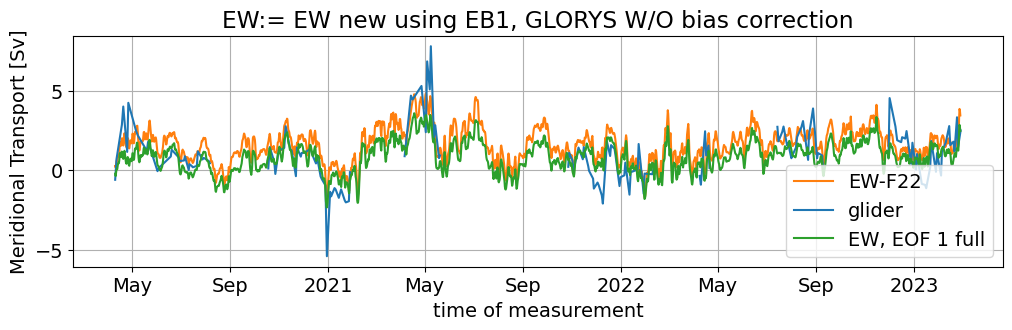

In [39]:
fig,axs = plt.subplots(1,1,figsize=[12,3])
ax=axs
rt_eof.plot_transport(Q_glider_nan,Q_rec_bias,Q_moor,ax=ax,mode_no=1,mean=False)

t_EW = Q_rec_bias.sel(mode=1,TIME=slice(ds_glider.TIME.min().values,ds_glider.TIME.max().values)
        ).interp_like(Q_glider_nan)
plt.title('EW:= EW new using EB1, GLORYS W/O bias correction')

Text(0.5, 1.0, 'EW:= EW new using only EB1')

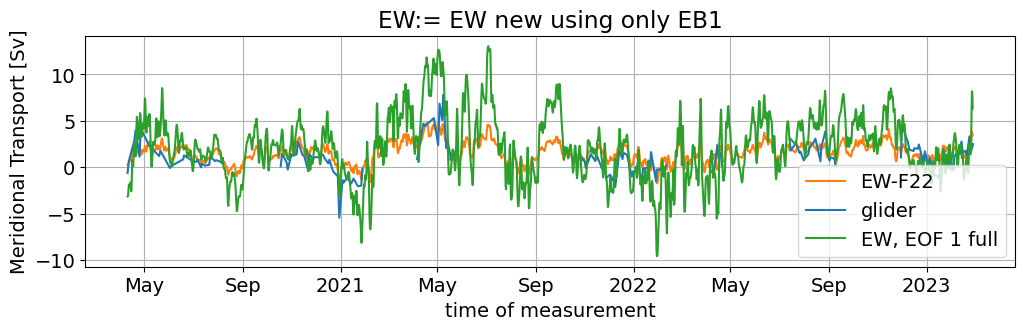

In [40]:
fig,axs = plt.subplots(1,1,figsize=[12,3])
ax=axs
rt_eof.plot_transport(Q_glider_nan,Q_rec_EB1,Q_moor,ax=ax,mode_no=1,mean=False)
plt.title('EW:= EW new using only EB1')

Text(0.5, 1, 'EW new using EB1, GLORYS with bias correction')

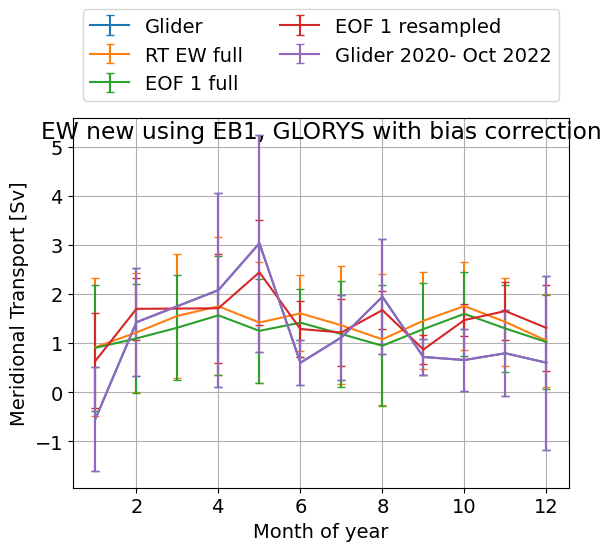

In [41]:
fig,axs = plt.subplots(1,1)
ax=axs
rt_eof.plot_seasonal_cycle_Q(Q_glider_nan,Q_rec,Q_moor,ax=ax,mode_no=1,mean=False)
plt.title('EW new using EB1, GLORYS with bias correction',y=1,pad=-14)

Text(0.5, 1, 'EW new using EB1, GLORYS W/O bias correction')

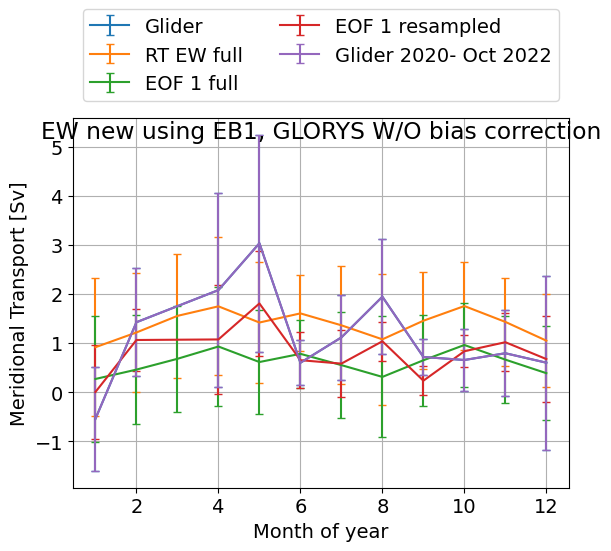

In [42]:
fig,axs = plt.subplots(1,1)
ax=axs
rt_eof.plot_seasonal_cycle_Q(Q_glider_nan,Q_rec_bias,Q_moor,ax=ax,mode_no=1,mean=False)
plt.title('EW new using EB1, GLORYS W/O bias correction',y=1,pad=-14)

Text(0.5, 1, 'EW new using only EB1')

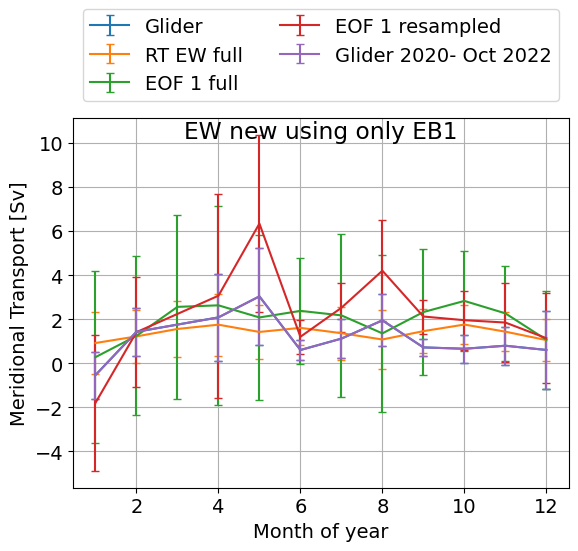

In [43]:
fig,axs = plt.subplots(1,1)
ax=axs
rt_eof.plot_seasonal_cycle_Q(Q_glider_nan,Q_rec_EB1,Q_moor,ax=ax,mode_no=1,mean=False)

plt.title('EW new using only EB1',y=1,pad=-14)